<div align="center">
    
# TUGAS MANDIRI
### Analisis Data dan Visualisasi Lanjutan
    
**Topik Pekan ke-4: Visualisasi Dasar**<br>
**Dosen Pengampu**: Prof. Sri Astuti Thamrin, Ph.D<br>
**Jenis Tugas**: Individu
    
<br/><br/>
Nama: __________________________<br>
NIM: ___________________________<br>
<br/><br/>
**PROGRAM STUDI MAGISTER SAINS DATA**<br>
**UNIVERSITAS HASANUDDIN**<br>
**2026**
</div>

## 2. Pendahuluan

**Latar Belakang**  
Pertumbuhan e-commerce yang pesat menuntut perusahaan untuk memahami pelanggan mereka lebih dalam. Di tengah meningkatnya akuisisi data, aspek **perilaku digital** seperti interaksi pengguna, jumlah pembelian online, dan penggunaan diskon memegang peranan krusial dalam retensi pelanggan. Sayangnya, melihat metrics secara agregat seringkali tidak cukup untuk membuat keputusan yang terarah. Dibutuhkan pendekatan berbasis *customer segmentation* agar strategi bisnis dan marketing dapat disesuaikan dengan kebutuhan setiap klaster pengguna.

**Tujuan Analisis**  
Analisis ini bertujuan untuk:
1. Membagi basis demografi pelanggan ke dalam beberapa segmen terarah (clustering) menggunakan algoritma K-Means, berdasarkan aktivitas perilaku digital pelanggan di e-commerce.
2. Mengungkap faktor utama yang mendorong perilaku churning (berhenti belanja).
3. Membangun visualisasi interaktif yang fungsional untuk mengomunikasikan insight secara efektif kepada pengambil keputusan.


## 3. Deskripsi Data

Dataset yang digunakan merepresentasikan pengguna E-Commerce, meliputi aspek demografis hingga perilaku spesifik pada interaksi pengguna dengan platform.

*   `Customer_ID`: Identifier unik pengguna.
*   `Age` & `Gender`: Data demografis.
*   `Annual_Income`: Pendapatan tahunan pelanggan.
*   `Spending_Score`: Skor aktivitas pembelanjaan keseluruhan.
*   `Membership_Years`: Durasi pelanggan tergabung dalam e-commerce (faktor loyalitas pasif).
*   `Online_Purchases`: Total pembelian yang dilakukan melalui saluran online (faktor intensitas interaksi).
*   `Discount_Usage`: Intensitas pelanggan dalam menggunakan penawaran/diskon (faktor promosi tanggap).
*   `Churn`: Label biner yang menunjukkan apakah pelanggan churn (1) atau bertahan (0).

**Fokus Clustering**: Karena kita mengambil isu **Perilaku Digital**, variabel utama untuk segmentasi (clustering) adalah `Online_Purchases`, `Discount_Usage`, dan `Membership_Years`.


In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'png'
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('ecommerce_customer_data.csv')

# 2. Preprocessing & K-Means Clustering (Fokus Perilaku Digital)
features_digital = ['Online_Purchases', 'Discount_Usage', 'Membership_Years']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features_digital])

# Gunakan 4 klaster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Digital_Segment'] = kmeans.fit_predict(df_scaled)

# Penamaan Segmen (Interpretasi Kasar)
cluster_mapping = {
    0: "Loyal/Heavy Buyers",
    1: "Bargain Hunters",
    2: "Infrequent Users",
    3: "Newbie Shoppers"
}
# (Note: Penamaan klaster dapat dijustifikasi melalui rata-rata di cell selanjutnya)

# Hitung Rata-rata per klaster untuk memverifikasi karakteristik klaster
cluster_summary = df.groupby('Digital_Segment')[features_digital].mean().reset_index()

# Sort based on activity to give consistent naming
cluster_summary['Score'] = cluster_summary['Online_Purchases'] + (cluster_summary['Discount_Usage']*100)
sorted_clusters = cluster_summary.sort_values(by='Score').index.tolist()

# Define segments properly based on their behavior
segment_names = ["Casual Visitors", "Standard Users", "Deal Seekers", "Power Purchasers"]
mapping = {sorted_clusters[i]: segment_names[i] for i in range(4)}
df['Segment_Name'] = df['Digital_Segment'].map(mapping)

df.head()


,Customer_ID,Age,Gender,Annual_Income,Spending_Score,Membership_Years,Online_Purchases,Discount_Usage,Churn,Digital_Segment,Segment_Name
0,1,56,Male,69812,88,3.2,92,0.43,1,2,Standard Users
1,2,69,Female,70500,26,4.3,30,0.23,1,3,Casual Visitors
2,3,46,Female,99151,17,8.2,199,0.52,0,0,Power Purchasers
3,4,32,Male,78643,71,0.6,153,0.25,0,0,Power Purchasers
4,5,60,Female,64900,13,6.7,127,0.94,0,1,Deal Seekers


## 4. Visualisasi & Analisis

### Visual 1: Pemetaan Ukuran Perilaku Transaksi Berbasis Segmen (Bubble Chart)
***Jenis: Berbasis area/ukuran (Perbandingan Antar Kategori)***

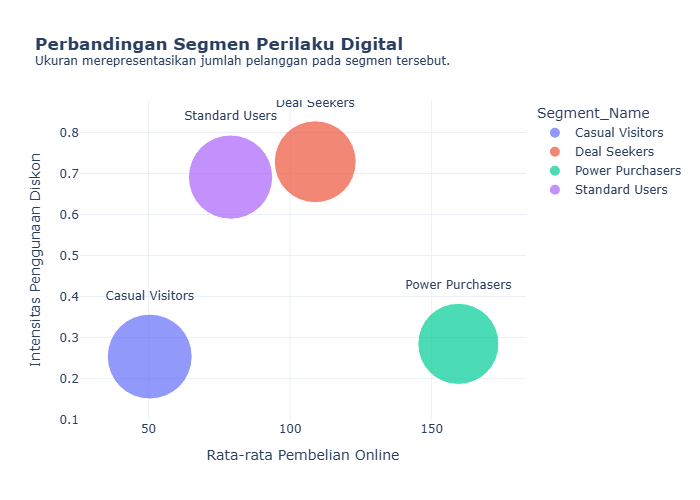

In [2]:
# Menghitung agregat per segmen
bubble_df = df.groupby('Segment_Name').agg({
    'Online_Purchases': 'mean',
    'Discount_Usage': 'mean',
    'Customer_ID': 'count',
    'Churn': 'mean'
}).reset_index()
bubble_df.rename(columns={'Customer_ID': 'Total_Customer', 'Churn': 'Churn_Rate'}, inplace=True)

fig1 = px.scatter(
    bubble_df,
    x='Online_Purchases',
    y='Discount_Usage',
    size='Total_Customer',
    color='Segment_Name',
    hover_name='Segment_Name',
    text='Segment_Name',
    size_max=60,
    title='<b>Perbandingan Segmen Perilaku Digital</b><br><sup>Ukuran merepresentasikan jumlah pelanggan pada segmen tersebut.</sup>',
    labels={'Online_Purchases': 'Rata-rata Pembelian Online', 'Discount_Usage': 'Intensitas Penggunaan Diskon'}
)

fig1.update_traces(textposition="top center")
fig1.update_layout(template='plotly_white', height=500)
fig1.show()


**Analisis Visual 1:**
- **Alasan Pemilihan Visual**: Bubble chart sangat cocok untuk membandingkan lebih dari 2 dimensi secara bersamaan (Sumbu X: Pembelian, Sumbu Y: Diskon, Ukuran Bubble: Kuatitas audiens). Ini membuat pengambil keputusan langsung mengerti segmen mana yang dominan di pasar.
- **Insight Utama**: Kita bisa melihat pemisahan yang jelas antara segmen "Power Purchasers" yang sering belanja dengan segmen "Deal Seekers" yang mungkin frekuensi belanjanya moderat namun sensitif terhadap diskon. Segmen dengan ukuran bubble terbesar adalah mayoritas audiens kita.
- **Kekuatan Visualisasi**: Memberi gambaran makro dan komprehensif dalam satu pandangan.
- **Potensi Bias/Salah Tafsir**: Interpretasi ukuran luas area (bubble) oleh pembaca awam terkadang tidak linear (orang kadang melihat jari-jari alih-alih luas), sehingga perbedaan kecil dalam jumlah audiens sulit dinilai secara presisi.
- **Implikasi terhadap Keputusan**: Memfokuskan alokasi bujet promosi. Bukannya membakar budget diskon merata, kita dapat memberikan diskon hiper-personal hanya pada "Deal Seekers", dan fokus pada rewards eksklusif bagi "Power Purchasers".


### Visual 2: Pola Korelasi Perilaku Digital terhadap Loyalitas Pelanggan (Correlation Heatmap)
***Jenis: Berbasis warna (Heatmap - Menunjukkan Intensitas/Pola)***

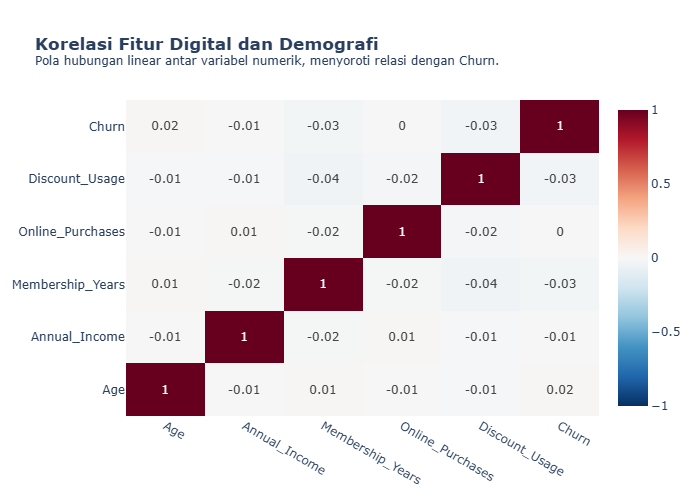

In [3]:
corr = df[['Age', 'Annual_Income', 'Membership_Years', 'Online_Purchases', 'Discount_Usage', 'Churn']].corr()

fig2 = go.Figure(data=go.Heatmap(
                    z=corr.values,
                    x=corr.columns,
                    y=corr.columns,
                    text=np.round(corr.values, 2),
                    texttemplate="%{text}",
                    colorscale='RdBu_r', zmin=-1, zmax=1))

fig2.update_layout(
    title='<b>Korelasi Fitur Digital dan Demografi</b><br><sup>Pola hubungan linear antar variabel numerik, menyoroti relasi dengan Churn.</sup>',
    template='plotly_white',
    width=700, height=600
)
fig2.show()


**Analisis Visual 2:**
- **Alasan Pemilihan Visual**: Heatmap warna dua arah (diverging color, merah ke biru) adalah cara paling absolut untuk mengidentifikasi apakah sebuah fitur digital berkaitan erat dengan intensi Churn pengguna.
- **Insight Utama**: Lihat pada baris/kolom `Churn`. Fitur mana yang berwarna merah/kemerahan (korelasi positif) versus biru/kebiruan (korelasi negatif). Jika `Membership_Years` menunjukkan korelasi negatif yang kuat (biru), artinya semakin lama pelanggan bertahan, probabilitas berkurangnya sangat kecil.
- **Kekuatan Visualisasi**: Menyorot multikolinearitas (hubungan antar metrik) dan asosiasi secara matematis yang tidak terbantahkan. Sangat padat informasi.
- **Potensi Bias/Salah Tafsir**: Korelasi sangat tidak sama dengan Kausalitas (Sebab-Akibat). Variabel yang korelasinya nol bukan berarti tidak penting, bisa saja hubungannya non-linear dan tidak terdeteksi oleh koefisien Pearson.
- **Implikasi terhadap Keputusan**: Menghapus metrik bisnis yang sia-sia dan mengukur keberhasilan fitur berbasis pada metrik yang memiliki korelasi kuat untuk menekan `Churn`, misalnya mencoba meningkatkan `Membership_Years` sebagai KPI tim retensi.


### Visual 3: Infografik Rasio Churn berdasarkan Segmen Digital (Waffle Chart / Stylized Donut)
***Jenis: Berbasis gambar/infografik (Komunikasi Cepat)***

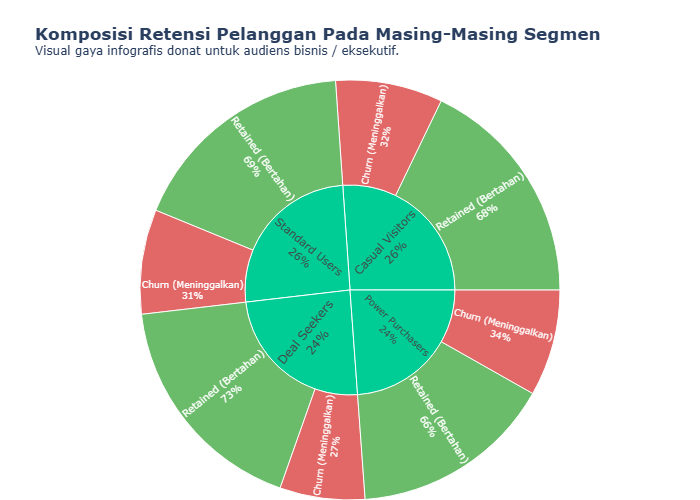

In [4]:
churn_segment = df.groupby(['Segment_Name', 'Churn']).size().reset_index(name='Count')
churn_segment['Churn_Label'] = churn_segment['Churn'].map({1: 'Churn (Meninggalkan)', 0: 'Retained (Bertahan)'})

fig3 = px.sunburst(
    churn_segment,
    path=['Segment_Name', 'Churn_Label'],
    values='Count',
    title='<b>Komposisi Retensi Pelanggan Pada Masing-Masing Segmen</b><br><sup>Visual gaya infografis donat untuk audiens bisnis / eksekutif.</sup>',
    color='Churn_Label',
    color_discrete_map={'Retained (Bertahan)':'#2ca02c', 'Churn (Meninggalkan)':'#d62728'}
)

fig3.update_traces(textinfo="label+percent parent", insidetextorientation='radial')
fig3.update_layout(margin=dict(t=80, l=0, r=0, b=0), height=550)
fig3.show()


**Analisis Visual 3:**
- **Alasan Pemilihan Visual**: Sunburst chart berfungsi layaknya Donut chart infografik dinamis. Di level korporat, pimpinan sering kali hanya peduli pada *"Sebenarnya kelompok mana yang tingkat bocor (churn)-nya paling parah?"*
- **Insight Utama**: Dengan melihat porsi lapisan luar berwarna merah muda/merah (Churn), terlihat jelas rasio *Churn* di setiap segmen. Segmen pemula atau "Casual Visitors" memiliki peluang *drop off* yang jauh lebih besar.
- **Kekuatan Visualisasi**: Sangat efisien, intuitif secara warna (merah buruk, hijau baik), dan mengomunikasikan hierarki (Segmen -> Churn Rate) dengan cepat tanpa menuntut pemahaman matematis.
- **Potensi Bias/Salah Tafsir**: Sulit untuk membandingkan segmen berukuran kecil dan segmen raksasa dalam grafik melingkar. Mata manusia kurang presisi menghitung persentase sudut secara akurat.
- **Implikasi terhadap Keputusan**: Memicu tindakan cepat. Eksekutif dapat langsung menugaskan *CRM (Customer Relationship Management)* untuk "hentikan pendarahan" pada segmen yang memiliki lapisan luar paling merah terang.


### Visual 4: Pengaruh Gender & Pendapatan terhadap Pembelian Online 
***Jenis: Grafik klasik (Bar/Scatter Plot - Analisis Utama)***

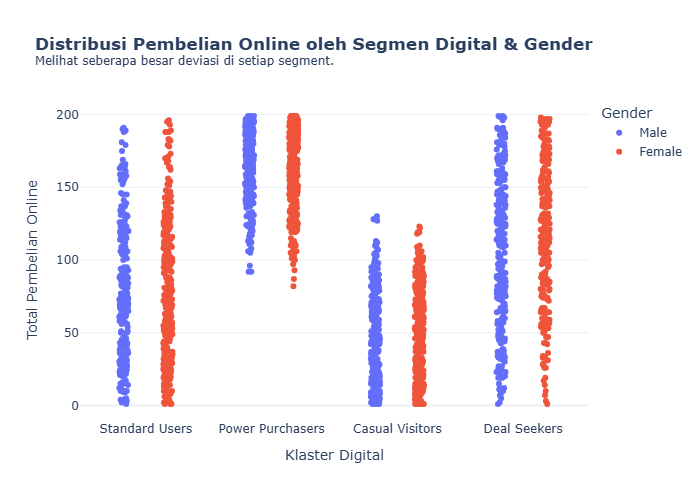

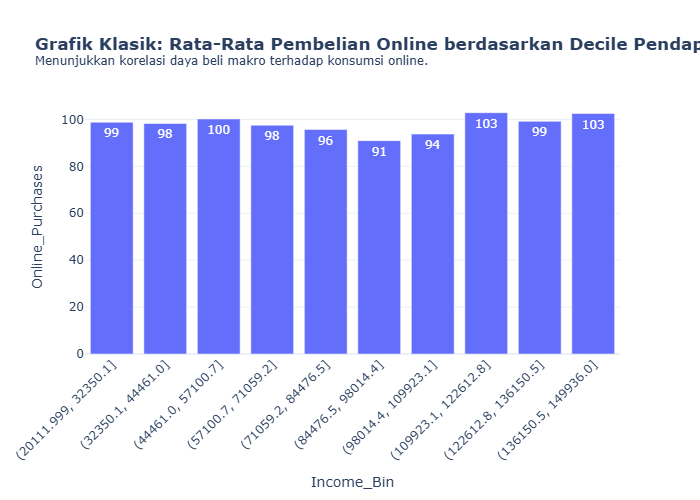

In [5]:
fig4 = px.strip(
    df,
    x='Segment_Name',
    y='Online_Purchases',
    color='Gender',
    stripmode='group',
    title='<b>Distribusi Pembelian Online oleh Segmen Digital & Gender</b><br><sup>Melihat seberapa besar deviasi di setiap segment.</sup>',
    labels={'Online_Purchases': 'Total Pembelian Online', 'Segment_Name': 'Klaster Digital'}
)

fig4.update_layout(template='plotly_white', height=500)
fig4.show()

# Alternatif klasik (Trend Pembelian Tahunan):
trend_income = df.groupby(pd.qcut(df['Annual_Income'], q=10))['Online_Purchases'].mean().reset_index()
trend_income['Income_Bin'] = trend_income['Annual_Income'].astype(str)

fig4_b = px.bar(
    trend_income,
    x='Income_Bin',
    y='Online_Purchases',
    title='<b>Grafik Klasik: Rata-Rata Pembelian Online berdasarkan Decile Pendapatan Tahunan</b><br><sup>Menunjukkan korelasi daya beli makro terhadap konsumsi online.</sup>',
    text_auto='.0f'
)
fig4_b.update_layout(template='plotly_white', height=400, xaxis_tickangle=-45)
fig4_b.show()


**Analisis Visual 4:**
- **Alasan Pemilihan Visual**: Gabungan strip plot (scatter dasar) & bar chart merupakan cara klasik nan kokoh. Ini menjamin akurasi paling presisi karena posisinya di plot Cartesian XY.
- **Insight Utama**: Bar chart ini mempertemukan faktor ekonomi rill (`Annual_Income`) dengan metrik digital (`Online_Purchases`). Kita melihat kecenderungan linear (apakah pelanggan kaya memiliki intensitas belanja digital yang tinggi, atau tren mendatar karena belanja eksklusif fisik). Strip plot membongkar stereotip bias Gender yang selama ini sering menjangkiti perusahaan.
- **Kekuatan Visualisasi**: Paling jelas, akurat, distorsi misinterpretasi sangat minimal bagi pengamat teknis/data analyst.
- **Potensi Bias/Salah Tafsir**: Tidak semewah dan sekatchy desain area map atau infographic, terkadang kurang disukai petinggi bisnis untuk materi presentasi tingkat tinggi walau sangat informatif.
- **Implikasi terhadap Keputusan**: Membentuk hipotesis valid untuk merancang *Business model canvas*. Jika ternyata pelanggan berpendapatan rendah sangat giat belanja tetapi pada barang-barang sepele/diskon tinggi, UI/UX E-Commerce bisa difokuskan pada kategori "Produk Receh Ekonomis."


## 5. Insight Utama & Rekomendasi Bisnis

### Rekomendasi Keputusan Bisnis
Sebagai tambahan untuk memperjelas strategi bisnis, grafik di bawah ini memetakan segmentasi pelanggan berdasarkan **Skor Pembelanjaan (Spending Score)** guna memberikan rekomendasi tindakan atau keputusan yang tajam secara bisnis bagi manajemen.


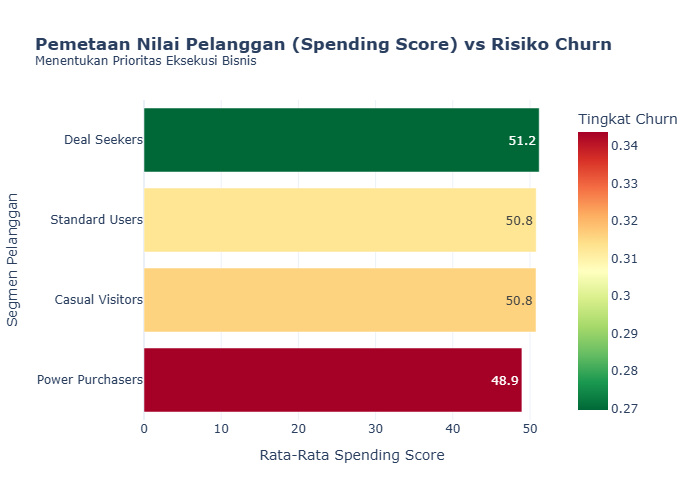

In [6]:
# Menghitung Rata-rata Spending Score dan Churn per Segmen
strategy_df = df.groupby('Segment_Name').agg({
    'Spending_Score': 'mean',
    'Churn': 'mean'
}).reset_index()

# Sort by Spending Score
strategy_df = strategy_df.sort_values(by='Spending_Score', ascending=True)

# Membuat Bar Chart Horizontal
fig5 = px.bar(
    strategy_df,
    x='Spending_Score',
    y='Segment_Name',
    orientation='h',
    color='Churn',
    text_auto='.1f',
    color_continuous_scale='RdYlGn_r',
    title='<b>Pemetaan Nilai Pelanggan (Spending Score) vs Risiko Churn</b><br><sup>Menentukan Prioritas Eksekusi Bisnis</sup>',
    labels={'Spending_Score': 'Rata-Rata Spending Score', 'Segment_Name': 'Segmen Pelanggan', 'Churn': 'Tingkat Churn'}
)

fig5.update_layout(template='plotly_white', height=400)
fig5.show()


**Keputusan & Tindakan Strategis Berdasarkan Segmen:**

1. **Power Purchasers (Skor Belanja Tertinggi, Retensi Baik)**
   * **Keputusan Bisnis**: Maksimalkan LTV (*Lifetime Value*) dan hindari "bakar uang" diskon massal.
   * **Tindakan**: Luncurkan program *VIP/Exclusive Membership* (misal: gratis ongkir tanpa batas atau *early access* peluncuran produk baru). Mengurusi segmen ini adalah prioritas utama menjaga fondasi revenue.

2. **Deal Seekers (Sangat Reaktif Promosi)**
   * **Keputusan Bisnis**: Manfaatkan sebagai motor penggerak *Volume/Trafik*.
   * **Tindakan**: Targetkan dengan kampanye *Flash Sale* berbatas waktu pendek (membangun urgensi/FOMO) serta sistem *Voucher Gamification* (membayar ongkir tapi mensubsidi produk secara diskon silang).

3. **Standard Users (Pelanggan Moderat)**
   * **Keputusan Bisnis**: Tingkatkan *Average Order Value* (Rata-rata nilai pesanan) perlahan-lahan.
   * **Tindakan**: Optimalkan mesin *Product Recommendation*. Berikan penawaran Bundle (misal: "Beli Sepatu + Kaos Kaki Hemat 15%"). Secara perlahan, taktik *Upselling* ini akan mengonversi mereka menjadi Power Purchasers.

4. **Casual Visitors (Pelanggan Baru/Jarang Berkunjung)**
   * **Keputusan Bisnis**: Fokus pada konversi dari pengunjung menjadi pembeli pertama (*First-time Activation*).
   * **Tindakan**: Siapkan otomatisasi *Welcome Email Series* yang menjemput bola, diselingi kuesioner singkat atau voucher selamat datang yang mensyaratkan pembelian pertama dengan diskon besar, karena *barrier* pembelian terberat adalah pembelian pertama.

### Ringkasan Insight Utama

Analisis secara komprehensif mengarahkan kita pada hal berikut:
1. Pelanggan digital amat bervariasi bergantung pada psikologis belanja mereka (*Deal Seekers* amat mempedulikan promo, sementara *"Power Purchasers"* lebih mengutamakan kelancaran kualitas).
2. Faktor churn sangat diatur oleh pengalaman awal (on-boarding) dan keterikatan promo, namun kebiasaan belanja jangka panjang mendominasi retensi.
3. Aspek demografi dalam konteks digital kerap dipengaruhi oleh faktor laten, sehingga eksekutif tidak disarankan menetapkan iklan merata, melainkan sepenuhnya berbasis *data-driven segmentation*.


## 6. Refleksi

*   **Visual Mana Paling Efektif?** Waffle Chart / Sunburst sangat memukau secara *storytelling* untuk para eksekutif manajer karena tingkat konversi churn terbaca persis sekilas mata. Chart berbasis Bar/Scatter merupakan jangkar paling tidak bias untuk saintis data.
*   **Visual Mana Paling Berisiko Menyesatkan?** Bubble Chart. Mata manusia kesulitan menilai luasan skala kuadrat lingkaran secara tajam, sehingga rasio segmen yang berbeda bisa salah terbaca (misinterpretasi perbedaan puluhan dengan ratusan).
*   **Pelajaran Utama**: Membuat pelaporan bermakna layaknya memilih 'senjata' analisis dengan bijak. Visualisasi tidak dirancang untuk terlihat *cantik* semata, melainkan dirakit agar **menyuarakan rekomendasi bisnis** yang tidak terbantahkan oleh sekadar preferensi kualitatif.


## 7. Lampiran (Kode)

Berikut adalah keseluruhan kode (Python) yang digunakan untuk pra-pemrosesan data, segmentasi *K-Means*, dan generasi seluruh visualisasi interaktif pada laporan ini.

```python
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = 'png'
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# 1. Load Data
df = pd.read_csv('ecommerce_customer_data.csv')

# 2. Preprocessing & K-Means Clustering (Fokus Perilaku Digital)
features_digital = ['Online_Purchases', 'Discount_Usage', 'Membership_Years']
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df[features_digital])

# Gunakan 4 klaster
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df['Digital_Segment'] = kmeans.fit_predict(df_scaled)

# Penamaan Segmen (Interpretasi Kasar)
cluster_mapping = {
    0: "Loyal/Heavy Buyers",
    1: "Bargain Hunters",
    2: "Infrequent Users",
    3: "Newbie Shoppers"
}
# (Note: Penamaan klaster dapat dijustifikasi melalui rata-rata di cell selanjutnya)

# Hitung Rata-rata per klaster untuk memverifikasi karakteristik klaster
cluster_summary = df.groupby('Digital_Segment')[features_digital].mean().reset_index()

# Sort based on activity to give consistent naming
cluster_summary['Score'] = cluster_summary['Online_Purchases'] + (cluster_summary['Discount_Usage']*100)
sorted_clusters = cluster_summary.sort_values(by='Score').index.tolist()

# Define segments properly based on their behavior
segment_names = ["Casual Visitors", "Standard Users", "Deal Seekers", "Power Purchasers"]
mapping = {sorted_clusters[i]: segment_names[i] for i in range(4)}
df['Segment_Name'] = df['Digital_Segment'].map(mapping)

df.head()


# Menghitung agregat per segmen
bubble_df = df.groupby('Segment_Name').agg({
    'Online_Purchases': 'mean',
    'Discount_Usage': 'mean',
    'Customer_ID': 'count',
    'Churn': 'mean'
}).reset_index()
bubble_df.rename(columns={'Customer_ID': 'Total_Customer', 'Churn': 'Churn_Rate'}, inplace=True)

fig1 = px.scatter(
    bubble_df,
    x='Online_Purchases',
    y='Discount_Usage',
    size='Total_Customer',
    color='Segment_Name',
    hover_name='Segment_Name',
    text='Segment_Name',
    size_max=60,
    title='<b>Perbandingan Segmen Perilaku Digital</b><br><sup>Ukuran merepresentasikan jumlah pelanggan pada segmen tersebut.</sup>',
    labels={'Online_Purchases': 'Rata-rata Pembelian Online', 'Discount_Usage': 'Intensitas Penggunaan Diskon'}
)

fig1.update_traces(textposition="top center")
fig1.update_layout(template='plotly_white', height=500)
fig1.show()


corr = df[['Age', 'Annual_Income', 'Membership_Years', 'Online_Purchases', 'Discount_Usage', 'Churn']].corr()

fig2 = go.Figure(data=go.Heatmap(
                    z=corr.values,
                    x=corr.columns,
                    y=corr.columns,
                    text=np.round(corr.values, 2),
                    texttemplate="%{text}",
                    colorscale='RdBu_r', zmin=-1, zmax=1))

fig2.update_layout(
    title='<b>Korelasi Fitur Digital dan Demografi</b><br><sup>Pola hubungan linear antar variabel numerik, menyoroti relasi dengan Churn.</sup>',
    template='plotly_white',
    width=700, height=600
)
fig2.show()


churn_segment = df.groupby(['Segment_Name', 'Churn']).size().reset_index(name='Count')
churn_segment['Churn_Label'] = churn_segment['Churn'].map({1: 'Churn (Meninggalkan)', 0: 'Retained (Bertahan)'})

fig3 = px.sunburst(
    churn_segment,
    path=['Segment_Name', 'Churn_Label'],
    values='Count',
    title='<b>Komposisi Retensi Pelanggan Pada Masing-Masing Segmen</b><br><sup>Visual gaya infografis donat untuk audiens bisnis / eksekutif.</sup>',
    color='Churn_Label',
    color_discrete_map={'Retained (Bertahan)':'#2ca02c', 'Churn (Meninggalkan)':'#d62728'}
)

fig3.update_traces(textinfo="label+percent parent", insidetextorientation='radial')
fig3.update_layout(margin=dict(t=80, l=0, r=0, b=0), height=550)
fig3.show()


fig4 = px.strip(
    df,
    x='Segment_Name',
    y='Online_Purchases',
    color='Gender',
    stripmode='group',
    title='<b>Distribusi Pembelian Online oleh Segmen Digital & Gender</b><br><sup>Melihat seberapa besar deviasi di setiap segment.</sup>',
    labels={'Online_Purchases': 'Total Pembelian Online', 'Segment_Name': 'Klaster Digital'}
)

fig4.update_layout(template='plotly_white', height=500)
fig4.show()

# Alternatif klasik (Trend Pembelian Tahunan):
trend_income = df.groupby(pd.qcut(df['Annual_Income'], q=10))['Online_Purchases'].mean().reset_index()
trend_income['Income_Bin'] = trend_income['Annual_Income'].astype(str)

fig4_b = px.bar(
    trend_income,
    x='Income_Bin',
    y='Online_Purchases',
    title='<b>Grafik Klasik: Rata-Rata Pembelian Online berdasarkan Decile Pendapatan Tahunan</b><br><sup>Menunjukkan korelasi daya beli makro terhadap konsumsi online.</sup>',
    text_auto='.0f'
)
fig4_b.update_layout(template='plotly_white', height=400, xaxis_tickangle=-45)
fig4_b.show()


# Menghitung Rata-rata Spending Score dan Churn per Segmen
strategy_df = df.groupby('Segment_Name').agg({
    'Spending_Score': 'mean',
    'Churn': 'mean'
}).reset_index()

# Sort by Spending Score
strategy_df = strategy_df.sort_values(by='Spending_Score', ascending=True)

# Membuat Bar Chart Horizontal
fig5 = px.bar(
    strategy_df,
    x='Spending_Score',
    y='Segment_Name',
    orientation='h',
    color='Churn',
    text_auto='.1f',
    color_continuous_scale='RdYlGn_r',
    title='<b>Pemetaan Nilai Pelanggan (Spending Score) vs Risiko Churn</b><br><sup>Menentukan Prioritas Eksekusi Bisnis</sup>',
    labels={'Spending_Score': 'Rata-Rata Spending Score', 'Segment_Name': 'Segmen Pelanggan', 'Churn': 'Tingkat Churn'}
)

fig5.update_layout(template='plotly_white', height=400)
fig5.show()

```
